# Notebook for finding optimal sensor locations for the airfoil prediction application using Bayesian experimental design method

In [1]:
import torch
import numpy as np
import math
import random
from scipy.interpolate import interp1d, CubicSpline, PchipInterpolator
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["mathtext.fontset"]= 'cm'  # Use Computer Modern for math
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [ ]:
#### For local runtime and local data files:
%cd C:/path/to/data/folder

C:\Users\10233\Box\Research\Data\Data_Processing


In [3]:
# ==========================================
# GPU Configuration
# ==========================================
USE_GPU = True
device = torch.device('cuda' if USE_GPU and torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
data1 = load_pressure("airfoil_11_wall2_surfacepressure_span.dat")

(30851, 189)


In [ ]:
def load_x_coords(filepath):
    # Read the first line separately for nx
    with open(filepath, 'r') as f:
        first_line = f.readline()
        nx = int(first_line.replace(',', ' ').split()[0])

    # Read the rest using pandas with regex separator
    df = pd.read_csv(filepath, sep=r'[,\s]+', engine='python', skiprows=1, header=None)

    # Grab the first column as a numpy array
    X_coords = df.iloc[:, 0].to_numpy()

    return nx, X_coords

def load_pressure(filepath):
  # If the file has a mix of commas and spaces, we can replace commas on the fly
  with open(filepath, 'r') as f:
    data1 = np.loadtxt((line.replace(',', ' ') for line in f))

  return data1

def load_and_preprocess_data(data_path, device, nt_train = 15000, CL_bins = 15):
    # Load CL and P data. Interpolate data from original grid to reference grid. Bin CL data.
    datasets = ["airfoil_5", "airfoil_11", "cylinder_5", "cylinder_11", "cylinder_0_5_1"]
    # nt_train = 18000
    # CL_bins = 15

    # 1. Load Reference Grid (from cylinder_5, which is index 2)
    nx, X_ref = load_x_coords(datasets[2]+"_xy_sort_wall1.dat")
    X_ref = X_ref[:nx]
    # ref_coord1 = np.loadtxt(os.path.join(data_path, f"{datasets[2]}), delimiter=",", skiprows=1)
    # nx = int(ref_coord1[0, 0])
    # X_ref = ref_coord1[1:nx+1, 0]

    # ref_coord2 = np.loadtxt(os.path.join(data_path, f"{datasets[2]}_xy_sort_wall2.dat"), delimiter=",", skiprows=1)
    # X2_ref = ref_coord2[1:nx+1, 0]
    _, X2_ref = load_x_coords(datasets[2]+"_xy_sort_wall2.dat")
    X2_ref = X2_ref[:nx]

    P_superposed = []
    CL_superposed = []

    # 2. Iterate through datasets
    for ds in datasets:
        # Load surface pressure data (Wall 1 and Wall 2)
        # data1 = np.load(os.path.join(data_path, f"{ds}_wall1_surfacepressure_span.dat"))
        # data2 = np.load(os.path.join(data_path, f"{ds}_wall2_surfacepressure_span.dat"))
        # data1 = pd.read_csv(os.path.join(data_path, f"{ds}_wall1_surfacepressure_span.dat"), sep=r'[,\s]+', engine='python').to_numpy()
        # data1 = pd.read_csv(os.path.join(data_path, f"{ds}_wall2_surfacepressure_span.dat"), sep=r'[,\s]+', engine='python').to_numpy()
        data1 = load_pressure(os.path.join(data_path, f"{ds}_wall1_surfacepressure_span.dat"))
        data2 = load_pressure(os.path.join(data_path, f"{ds}_wall2_surfacepressure_span.dat"))

        time = data1[:, 0]

        # Load and interpolate CL data
        # CL_raw = np.loadtxt(os.path.join(data_path, f"{ds}_CL.csv")) # Assuming CSV for readmatrix
        CL_raw = pd.read_csv(os.path.join(data_path, f"{ds}_CL.csv"), header=None).to_numpy()
        time_CL = CL_raw[:, 0]
        CL_vals = CL_raw[:, 1]

        cl_interp = CubicSpline(time_CL, CL_vals, extrapolate=True)
        CL_q = cl_interp(time)[:nt_train]

        # Normalize CL
        CL_nor = (CL_q - np.mean(CL_q)) / (np.max(CL_q) - np.min(CL_q))
        CL_superposed.append(CL_nor)

        # 3. Spatial Interpolation
        if ds == "cylinder_5":
            P1_all = data1[:nt_train, 1:]
            P2_all = data2[:nt_train, 1:]

        else:
            # Load local coordinates for the current dataset
            # coord1 = np.loadtxt(os.path.join(data_path, f"{ds}_xy_sort_wall1.dat"), delimiter=",", skiprows=1)
            # nx_local1 = int(coord1[0, 0])
            nx_local1, coord1 = load_x_coords(ds+"_xy_sort_wall1.dat")
            X_temp1 = coord1[:nx_local1]


            # coord2 = np.loadtxt(os.path.join(data_path, f"{ds}_xy_sort_wall2.dat"), delimiter=",", skiprows=1)
            # nx_local2 = int(coord2[0, 0])
            nx_local2, coord2 = load_x_coords(ds+"_xy_sort_wall2.dat")
            X_temp2 = coord2[:nx_local2]

            P1_all = np.zeros((nt_train, nx))
            P2_all = np.zeros((nt_train, nx))

            # Interpolate pressure to reference grid (PchipInterpolator approximates MATLAB's 'makima')
            for t in range(nt_train):
                f1 = PchipInterpolator(X_temp1, data1[t, 1:], extrapolate=True)
                P1_all[t, :] = f1(X_ref)

                f2 = PchipInterpolator(X_temp2, data2[t, 1:], extrapolate=True)
                P2_all[t, :] = f2(X2_ref)

        # Concatenate wall 1 and wall 2
        P_all = np.hstack((P1_all, P2_all))
        P_superposed.append(P_all)

    return P_superposed, CL_superposed, nx


# ==========================================
#NMC with Importance Sampling
# ==========================================
def compute_EIG(candidate_sensor, selected_sensors):
    """
    Computes EIG using Nested Monte Carlo with Importance Sampling.
    Instead of drawing inner samples blindly from the prior, we bias the sampling
    towards the true outer parameter to reduce variance.
    """
    active_sensors = selected_sensors + [candidate_sensor]

    # Extract sub-matrices for the currently active sensors
    mu_active = mu_bins[:, active_sensors]                 # (CL_bins, n_active)
    cov_active = cov_bins[:, active_sensors][:, :, active_sensors] # (CL_bins, n_active, n_active)

    # Create batched Multivariate Normal distribution for likelihood evaluations
    likelihood_dist = torch.distributions.MultivariateNormal(mu_active, cov_active)

    # OUTER LOOP: Sample N parameter bins from the prior (uniform over bins for simplicity)
    theta_outer = torch.randint(0, CL_bins, (n_mc_outer,), device=device)

    # Sample observation Y from p(Y | theta_outer)
    y_outer = likelihood_dist.sample((n_mc_outer,)) # (n_mc_outer, CL_bins, n_active)
    y_outer = y_outer[torch.arange(n_mc_outer), theta_outer, :] # Select the matching Ys: (n_mc_outer, n_active)

    # Compute log p(Y | theta_outer)
    log_p_y_given_theta_outer = likelihood_dist.log_prob(y_outer.unsqueeze(1)) # (n_mc_outer, CL_bins)
    log_p_y_given_theta_outer = log_p_y_given_theta_outer[torch.arange(n_mc_outer), theta_outer]

    # INNER LOOP with IMPORTANCE SAMPLING:
    # Bias inner samples to be close to the outer sample (e.g., adjacent bins)
    # Proposal q(theta_inner): 80% chance true outer bin, 20% random prior bin
    is_mask = torch.rand((n_mc_outer, n_mc_inner), device=device) < 0.8
    theta_inner_random = torch.randint(0, CL_bins, (n_mc_outer, n_mc_inner), device=device)
    theta_inner = torch.where(is_mask, theta_outer.unsqueeze(1).expand(-1, n_mc_inner), theta_inner_random)

    # Compute Importance Weights: w = p(theta) / q(theta)
    # p(theta) = 1 / CL_bins
    # q(theta) = 0.8 (if same) + 0.2 * (1/CL_bins) (if random)
    p_theta = 1.0 / CL_bins
    q_theta = torch.where(theta_inner == theta_outer.unsqueeze(1),
                          0.8 + 0.2 * p_theta,
                          0.2 * p_theta * torch.ones_like(theta_inner, dtype=torch.float32))
    weights = p_theta / q_theta

    # Compute log p(Y | theta_inner)
    # Expand Y for broadcasting: (n_mc_outer, 1, n_active)
    log_p_y_given_theta_inner = likelihood_dist.log_prob(y_outer.unsqueeze(1)) # (n_mc_outer, CL_bins)

    # Gather the likelihoods for the specific inner samples: (n_mc_outer, n_mc_inner)
    inner_likelihoods = log_p_y_given_theta_inner.gather(1, theta_inner)

    # Estimate evidence: 1/M * sum( L * weights )
    weighted_likelihoods = torch.exp(inner_likelihoods) * weights
    evidence = weighted_likelihoods.mean(dim=1)
    log_evidence = torch.log(evidence + 1e-10) # Avoid log(0)

    # EIG = mean( log p(Y|theta) - log p(Y) )
    eig = (log_p_y_given_theta_outer - log_evidence).mean().item()
    return eig

def compute_EIG_exchange(active_sensors):
    """
    Computes Expected Information Gain (EIG) for a specific set of active sensors.
    """
    # Extract only the means and covariances corresponding to the active sensor locations.
    mu_active = mu_bins[:, active_sensors]
    cov_active = cov_bins[:, active_sensors][:, :, active_sensors]

    # Create the Multivarate Normal distribution
    likelihood_dist = torch.distributions.MultivariateNormal(mu_active, cov_active)

    # --- OUTER LOOP ---
    theta_outer = torch.randint(0, CL_bins, (n_mc_outer,), device=device)
    y_outer = likelihood_dist.sample((n_mc_outer,))
    y_outer = y_outer[torch.arange(n_mc_outer), theta_outer, :]

    log_p_y_given_theta_outer = likelihood_dist.log_prob(y_outer.unsqueeze(1))
    log_p_y_given_theta_outer = log_p_y_given_theta_outer[torch.arange(n_mc_outer), theta_outer]

    # --- INNER LOOP (Importance Sampling) ---
    is_mask = torch.rand((n_mc_outer, n_mc_inner), device=device) < 0.8
    theta_inner_random = torch.randint(0, CL_bins, (n_mc_outer, n_mc_inner), device=device)
    theta_inner = torch.where(is_mask, theta_outer.unsqueeze(1).expand(-1, n_mc_inner), theta_inner_random)

    p_theta = 1.0 / CL_bins
    q_theta = torch.where(theta_inner == theta_outer.unsqueeze(1),
                          0.8 + 0.2 * p_theta,
                          0.2 * p_theta * torch.ones_like(theta_inner, dtype=torch.float32))
    weights = p_theta / q_theta

    log_p_y_given_theta_inner = likelihood_dist.log_prob(y_outer.unsqueeze(1))
    inner_likelihoods = log_p_y_given_theta_inner.gather(1, theta_inner)

    weighted_likelihoods = torch.exp(inner_likelihoods) * weights
    evidence = weighted_likelihoods.mean(dim=1)
    log_evidence = torch.log(evidence + 1e-10)

    eig = (log_p_y_given_theta_outer - log_evidence).mean().item()
    return eig

In [26]:
# Main
# datasets = ["airfoil_5", "airfoil_11", "cylinder_5", "cylinder_11", "cylinder_0_5_1"]
datasets = ["airfoil_5", "airfoil_11", "cylinder_5"]
nt_train = 18000      # Number of time steps/data points to load per dataset

# Load and pre-process data
P_superposed, CL_superposed, nx = load_and_preprocess_data("", device,nt_train=nt_train)
n_total_candidates = 2 * nx
P_superposed = np.vstack(P_superposed) # Final Aggregation
CL_superposed = np.concatenate(CL_superposed)

In [65]:
# Parameters
CL_bins = 18          # Number of discrete bins to categorize the continuous Lift Coefficient (CL)
n_mc_outer = 30000     # N: Number of outer loop samples (simulated true states of reality)
n_mc_inner = 5000      # M: Number of inner loop samples (used to estimate the marginal evidence)
p_sensors = 10        # Total number of optimal sensor locations to select
epsilon = 0.001        # Tolerance parameter controlling the stochastic greedy subsample size

# Binning
# Discretize CL into bins
counts, bin_edges = np.histogram(CL_superposed, bins=CL_bins)
CL_binned = np.digitize(CL_superposed, bin_edges) - 1
CL_binned = np.clip(CL_binned, 0, CL_bins - 1) # Ensure max value falls into the last bin

# Convert to PyTorch tensors and map to GPU/CPU device
P_data = torch.tensor(P_superposed, dtype=torch.float32, device=device)
CL_data = torch.tensor(CL_binned, dtype=torch.int64, device=device)
print("Data loaded")
print("CL_data:",CL_data.shape)
print("P_data:",P_data.shape)

# Precompute means and covariances for each CL bin for fast likelihood evaluation
# Shapes: Means (CL_bins, 2*nx), Covs (CL_bins, 2*nx, 2*nx)
mu_bins = torch.zeros((CL_bins, n_total_candidates), device=device)
cov_bins = torch.zeros((CL_bins, n_total_candidates, n_total_candidates), device=device)
for b in range(CL_bins):
    mask = (CL_data == b)
    if mask.sum() > 1:
        P_bin = P_data[mask]
        mu_bins[b] = P_bin.mean(dim=0)
        # Adding small jitter to diagonal for numerical stability
        # cov_bins[b] = torch.cov(P_bin.T) + torch.eye(n_total_candidates, device=device) * 1e-5
        sensor_noise_variance = 0.01 # Adds extra noise variance to mitigate correlation issues
        cov_bins[b] = torch.cov(P_bin.T) + torch.eye(n_total_candidates, device=device) * sensor_noise_variance

# # ==========================================
# # Fedorov's Exchange Optimization Algorithm
# # ==========================================
# print("Starting Fedorov's Exchange Optimization...")

# # Initialization
# unselected_sensors = list(range(n_total_candidates))
# selected_sensors = random.sample(unselected_sensors, p_sensors)

# for s in selected_sensors:
#     unselected_sensors.remove(s)

# current_eig = compute_EIG_exchange(selected_sensors)
# print(f"Initial Random Design EIG: {current_eig:.4f}\n")

# max_iterations = 15  # Limit iterations to prevent endless loops on flat objective surfaces

# for iteration in range(max_iterations):
#     best_swap = None
#     best_eig = current_eig

#     # Exhaustive Search
#     for i, s_in in enumerate(selected_sensors):
#         for j, s_out in enumerate(unselected_sensors):

#             # Create the proposed new design matrix by temporarily swapping the sensors
#             proposed_sensors = selected_sensors.copy()
#             proposed_sensors[i] = s_out

#             # Evaluate the utility of this specific swapped design
#             proposed_eig = compute_EIG_exchange(proposed_sensors)

#             # Keep track of the absolute best swap found in this iteration
#             if proposed_eig > best_eig:
#                 best_eig = proposed_eig
#                 best_swap = (s_in, s_out, i, j)  # (Old sensor, New sensor, Index in selected, Index in unselected)

#     # Execution
#     if best_swap is not None:
#         s_in, s_out, idx_in, idx_out = best_swap

#         # Execute the best swap found
#         selected_sensors[idx_in] = s_out
#         unselected_sensors[idx_out] = s_in
#         current_eig = best_eig

#         print(f"Iteration {iteration+1} | Swapped OUT node {s_in} for IN node {s_out} | New EIG: {current_eig:.4f}")
#     else:
#         # If no single swap improves the EIG, we have hit a local optimum and the algorithm converges.
#         print(f"\nConvergence reached at iteration {iteration+1}. No further improvements possible.")
#         break

# print("\nFinal Optimal Sensors:", sorted(selected_sensors))
# print(f"Final Expected Information Gain: {current_eig:.4f}")

# ==========================================
# Stochastic Greedy Optimization
# ==========================================
selected_sensors = []
candidates = list(range(n_total_candidates))

# Subsample size formula R = (|V| / p) * log(1/epsilon)
subset_size = min(len(candidates), math.ceil((len(candidates) / p_sensors) * math.log(1 / epsilon)))

print(f"Starting optimization. Subset size per step: {subset_size} / {len(candidates)}")

for q in range(p_sensors):
    # Stochastic Greedy: Evaluate only a random subset of available candidates
    random_subset = random.sample(candidates, subset_size)

    best_u = -float('inf')
    best_s = -1

    for s in random_subset:
        u = compute_EIG(s, selected_sensors)
        if u > best_u:
            best_u = u
            best_s = s

    selected_sensors.append(best_s)
    candidates.remove(best_s)
    print(f"Step {q+1}/{p_sensors} | Selected Sensor: {best_s} | EIG: {best_u:.4f}")

print("\nFinal Optimal Sensors:", selected_sensors)

Data loaded
CL_data: torch.Size([90000])
P_data: torch.Size([90000, 376])
Starting optimization. Subset size per step: 260 / 376
Step 1/10 | Selected Sensor: 37 | EIG: 0.5867
Step 2/10 | Selected Sensor: 0 | EIG: 0.8717
Step 3/10 | Selected Sensor: 226 | EIG: 1.0784
Step 4/10 | Selected Sensor: 191 | EIG: 1.2019
Step 5/10 | Selected Sensor: 82 | EIG: 1.3247
Step 6/10 | Selected Sensor: 55 | EIG: 1.4260
Step 7/10 | Selected Sensor: 350 | EIG: 1.5279
Step 8/10 | Selected Sensor: 241 | EIG: 1.6070
Step 9/10 | Selected Sensor: 143 | EIG: 1.6798
Step 10/10 | Selected Sensor: 23 | EIG: 1.7473

Final Optimal Sensors: [37, 0, 226, 191, 82, 55, 350, 241, 143, 23]


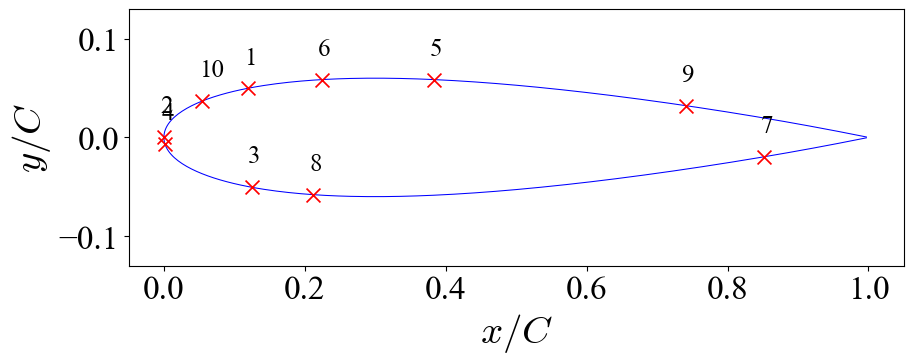

In [66]:
# Plot optimal sensor configuration
attr_sensors = selected_sensors

# Read the rest using pandas with regex separator
df = pd.read_csv("airfoil_5_xy_sort_wall1.dat", sep=r'[,\s]+', engine='python', skiprows=1, header=None)
X1 = df.iloc[:188, 0].to_numpy()
Y1 = df.iloc[:188, 1].to_numpy()
df = pd.read_csv("airfoil_5_xy_sort_wall2.dat", sep=r'[,\s]+', engine='python', skiprows=1, header=None)
X2 = df.iloc[:188, 0].to_numpy()
Y2 = df.iloc[:188, 1].to_numpy()

# Grab the first column as a numpy array
X_coords = df.iloc[:, 0].to_numpy()
plt.rcParams['figure.figsize'] = [10, 3.333] # change figure size
# plt.scatter(X1,Y1,marker='.', color='#bdd7e7')
# plt.scatter(X2,Y2,marker='.', color='#bdd7e7')
plt.plot(X1,Y1, linewidth= 0.75, color='b')
plt.plot(X2,Y2, linewidth= 0.75, color='b')
X_all = np.hstack((X1,X2))
Y_all = np.hstack((Y1,Y2))
plt.scatter(X_all[attr_sensors],Y_all[attr_sensors],marker='x', s=100, linewidths=1.25, color='r',zorder=10)
labels = np.arange(len(attr_sensors))+1
for i, txt in enumerate(labels):
  plt.annotate(str(txt), (X_all[attr_sensors[i]]-0.005, Y_all[attr_sensors[i]]+0.025), fontsize=18)

plt.xlabel(r'$x/C$')
plt.ylabel(r'$y/C$')
plt.ylim([-0.13,0.13])
plt.xlim([-0.05,1.05])
plt.show()